In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('/Users/nani/Documents/GitHub/data-viz-class-material/data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [3]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


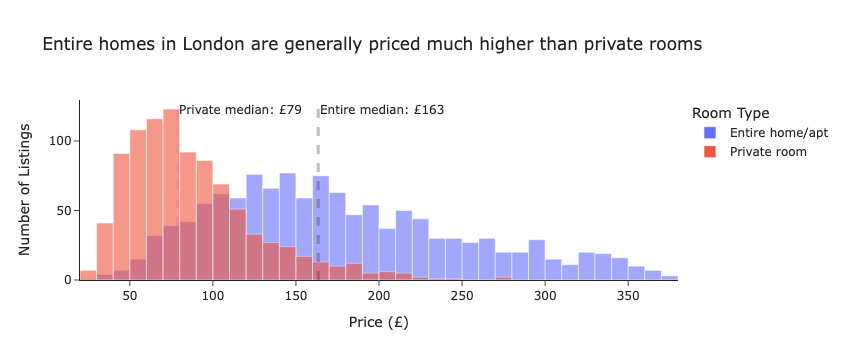

In [4]:
# Task 1 — Histogram: Price distribution by room type

# Filter only the two main room types
df_hist = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Median prices
median_entire = df_hist[df_hist['room_type'] == 'Entire home/apt']['price'].median()
median_private = df_hist[df_hist['room_type'] == 'Private room']['price'].median()

# Create histogram
fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=50,
    title='Entire homes in London are generally priced much higher than private rooms',
    labels={'price': 'Price (£)', 'room_type': 'Room Type'}
)

# Median lines
fig.add_vline(
    x=median_entire,
    line_dash='dash',
    line_width=3,
    line_color='#442220',
    annotation_text=f'Entire median: £{median_entire:.0f}'
)

fig.add_vline(
    x=median_private,
    line_dash='dash',
    line_width=3,
    line_color='#fe64a3',
    annotation_text=f'Private median: £{median_private:.0f}'
)

# Clean layout
fig.update_layout(
    template='simple_white',
    xaxis_title='Price (£)',
    yaxis_title='Number of Listings'
)

fig.show()

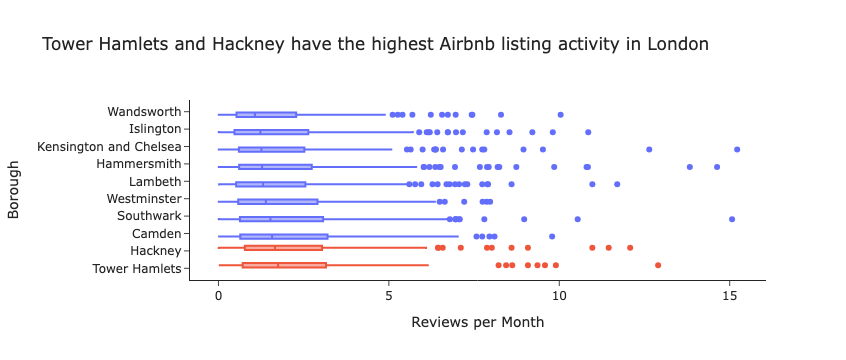

In [5]:
# Task 2 — Box plot: Listing activity by borough

# Remove listings with zero reviews
df_reviews = df[df['reviews_per_month'] > 0].copy()

# Get borough order by median reviews
borough_order = (
    df_reviews.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
)

# Top 2 busiest boroughs
top2 = borough_order.head(2).index.tolist()

# Create highlight column
df_reviews['highlight'] = np.where(
    df_reviews['neighbourhood'].isin(top2),
    'Top Boroughs',
    'Other Boroughs'
)

# Box plot
fig = px.box(
    df_reviews,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    category_orders={'neighbourhood': borough_order.index.tolist()},
    points='outliers',
    title=f'{top2[0]} and {top2[1]} have the highest Airbnb listing activity in London',
    labels={
        'reviews_per_month': 'Reviews per Month',
        'neighbourhood': 'Borough'
    }
)

# Clean layout
fig.update_layout(
    template='simple_white',
    showlegend=False,
    yaxis={'categoryorder': 'array', 'categoryarray': borough_order.index.tolist()}
)

fig.show()